# Authorship Attribution & Paraphraser Identification

**Ship of Theseus: Computational Forensics**

This notebook addresses **RQ2** (point of no return for authorship attribution) and **RQ3** (paraphraser fingerprint classification).

---

In [1]:
import sys
import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', font_scale=1.1)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.attribution.feature_builder import build_feature_vector, build_delta_features
from src.attribution.classifier import (
    run_attribution_experiment, run_paraphraser_identification, CLASSIFIERS
)
from src.utils.config import ALL_DATASETS, FIGURES_DIR, RANDOM_SEED

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / 'fingerprints').mkdir(exist_ok=True)

with open(PROJECT_ROOT / 'data' / 'processed' / 'multitier_results.pkl', 'rb') as f:
    multitier = pickle.load(f)

print(f'Loaded {len(multitier)} paraphrasers')
for k, df in multitier.items():
    print(f'  {k}: {len(df)} articles, sources: {sorted(df["source"].unique())}')


Loaded 7 paraphrasers
  chatgpt: 1562 articles, sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'PaLM', 'Tsinghua']
  palm: 508 articles, sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'OpenAI', 'PaLM', 'Tsinghua']
  dipper: 3010 articles, sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'OpenAI', 'PaLM', 'Tsinghua']
  dipper(low): 3014 articles, sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'OpenAI', 'PaLM', 'Tsinghua']
  dipper(high): 2990 articles, sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'OpenAI', 'PaLM', 'Tsinghua']
  pegasus(full): 3011 articles, sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'OpenAI', 'PaLM', 'Tsinghua']
  pegasus(slight): 3018 articles, sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'OpenAI', 'PaLM', 'Tsinghua']


---
## RQ2: Authorship Attribution — Point of No Return

Train classifiers on T0 features (original text) with source author as label. Evaluate on T1, T2, T3 features to measure how authorial identity decays.

### Binary Classification (Human vs LLM)

In [2]:
binary_results = {}
target_paraphrasers = ['dipper', 'dipper(low)', 'dipper(high)',
                       'pegasus(full)', 'pegasus(slight)', 'chatgpt']

LABELS = {
    'chatgpt': 'ChatGPT', 'dipper': 'Dipper', 'dipper(low)': 'Dipper (Low)',
    'dipper(high)': 'Dipper (High)', 'pegasus(full)': 'Pegasus (Full)',
    'pegasus(slight)': 'Pegasus (Slight)',
}

for para_key in target_paraphrasers:
    df = multitier[para_key]
    results, feat_names = run_attribution_experiment(
        df, build_feature_vector, label_col='source', binary=True
    )
    binary_results[para_key] = results
    print(f'\n{LABELS[para_key]} ({len(df)} articles):')
    for clf_name, tier_results in results.items():
        tiers_str = '  '.join(f'{t}: F1={m["macro_f1"]:.3f}' for t, m in tier_results.items())
        print(f'  {clf_name}: {tiers_str}')



Dipper (3010 articles):
  Logistic Regression: T0: F1=0.541  T1: F1=0.451  T2: F1=0.449  T3: F1=0.440
  SVM (RBF): T0: F1=0.757  T1: F1=0.571  T2: F1=0.541  T3: F1=0.530
  Random Forest: T0: F1=1.000  T1: F1=0.550  T2: F1=0.518  T3: F1=0.504



Dipper (Low) (3014 articles):
  Logistic Regression: T0: F1=0.539  T1: F1=0.477  T2: F1=0.477  T3: F1=0.471
  SVM (RBF): T0: F1=0.757  T1: F1=0.644  T2: F1=0.604  T3: F1=0.604
  Random Forest: T0: F1=1.000  T1: F1=0.637  T2: F1=0.613  T3: F1=0.582



Dipper (High) (2990 articles):
  Logistic Regression: T0: F1=0.544  T1: F1=0.352  T2: F1=0.354  T3: F1=0.349
  SVM (RBF): T0: F1=0.761  T1: F1=0.433  T2: F1=0.462  T3: F1=0.481
  Random Forest: T0: F1=1.000  T1: F1=0.496  T2: F1=0.488  T3: F1=0.469



Pegasus (Full) (3011 articles):
  Logistic Regression: T0: F1=0.541  T1: F1=0.499  T2: F1=0.469  T3: F1=0.461
  SVM (RBF): T0: F1=0.758  T1: F1=0.656  T2: F1=0.607  T3: F1=0.590
  Random Forest: T0: F1=1.000  T1: F1=0.524  T2: F1=0.493  T3: F1=0.483



Pegasus (Slight) (3018 articles):
  Logistic Regression: T0: F1=0.541  T1: F1=0.529  T2: F1=0.516  T3: F1=0.507
  SVM (RBF): T0: F1=0.758  T1: F1=0.744  T2: F1=0.724  T3: F1=0.700
  Random Forest: T0: F1=1.000  T1: F1=0.804  T2: F1=0.718  T3: F1=0.671



ChatGPT (1562 articles):
  Logistic Regression: T0: F1=0.637  T1: F1=0.419  T2: F1=0.401  T3: F1=0.401
  SVM (RBF): T0: F1=0.861  T1: F1=0.557  T2: F1=0.532  T3: F1=0.549
  Random Forest: T0: F1=1.000  T1: F1=0.677  T2: F1=0.649  T3: F1=0.672


### Attribution Decay Curves (F1 vs Paraphrase Depth)

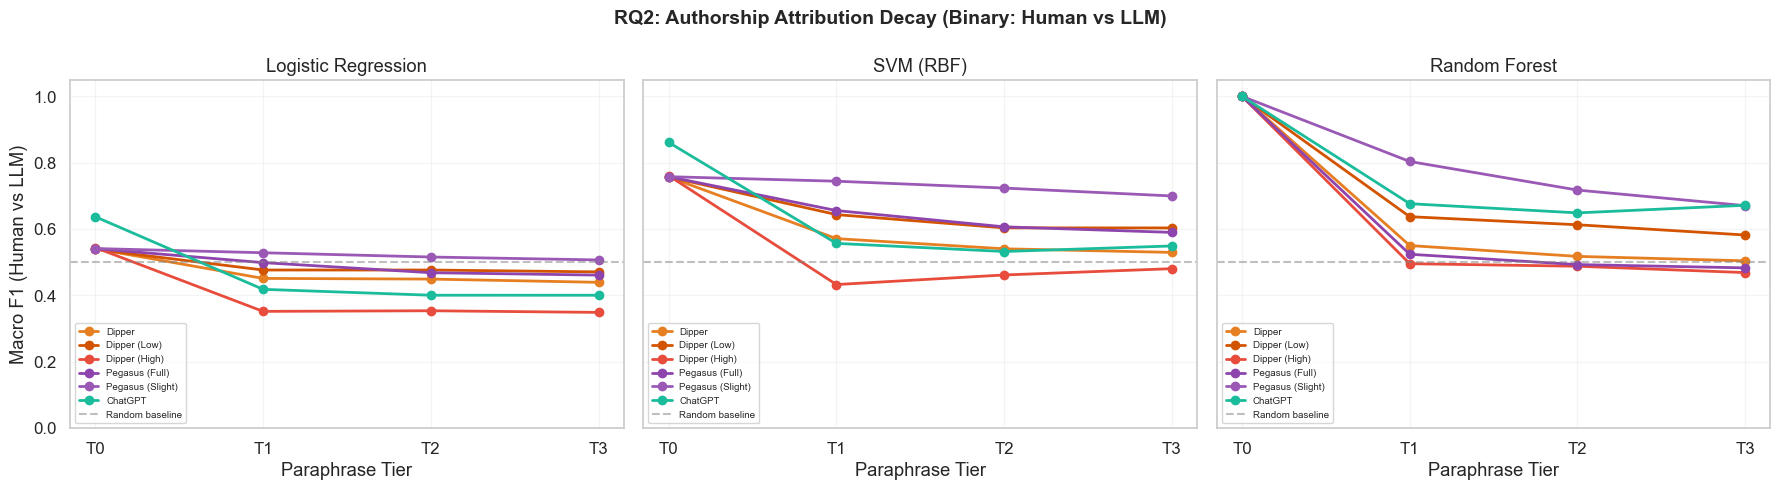

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
tiers = ['T0', 'T1', 'T2', 'T3']
x = range(len(tiers))

COLORS = {
    'chatgpt': '#1abc9c', 'dipper': '#e67e22', 'dipper(low)': '#d35400',
    'dipper(high)': '#e74c3c', 'pegasus(full)': '#8e44ad', 'pegasus(slight)': '#9b59b6',
}

for ax_idx, clf_name in enumerate(CLASSIFIERS.keys()):
    ax = axes[ax_idx]
    for para_key in target_paraphrasers:
        f1_vals = []
        for tier in tiers:
            if tier in binary_results[para_key][clf_name]:
                f1_vals.append(binary_results[para_key][clf_name][tier]['macro_f1'])
            else:
                f1_vals.append(np.nan)
        ax.plot(x, f1_vals, 'o-', label=LABELS[para_key],
                color=COLORS[para_key], linewidth=2, markersize=6)

    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(tiers)
    ax.set_xlabel('Paraphrase Tier')
    ax.set_title(clf_name)
    ax.set_ylim(0, 1.05)
    if ax_idx == 0:
        ax.set_ylabel('Macro F1 (Human vs LLM)')
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.2)

fig.suptitle('RQ2: Authorship Attribution Decay (Binary: Human vs LLM)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fingerprints' / 'attribution_decay_binary.png',
            dpi=300, bbox_inches='tight')
plt.show()


### Point of No Return Analysis

In [4]:
print('Point of No Return (tier where F1 first drops below 0.5):\n')
print(f'{"Paraphraser":<20s} {"Logistic Reg":>15s} {"SVM":>15s} {"Random Forest":>15s}')
print('-' * 70)
for para_key in target_paraphrasers:
    row = f'{LABELS[para_key]:<20s}'
    for clf_name in CLASSIFIERS.keys():
        tiers_data = binary_results[para_key][clf_name]
        point = 'Survives T3'
        for tier in ['T1', 'T2', 'T3']:
            if tier in tiers_data and tiers_data[tier]['macro_f1'] < 0.5:
                point = tier
                break
        row += f' {point:>15s}'
    print(row)


Point of No Return (tier where F1 first drops below 0.5):

Paraphraser             Logistic Reg             SVM   Random Forest
----------------------------------------------------------------------
Dipper                            T1     Survives T3     Survives T3
Dipper (Low)                      T1     Survives T3     Survives T3
Dipper (High)                     T1              T1              T1
Pegasus (Full)                    T1     Survives T3              T2
Pegasus (Slight)         Survives T3     Survives T3     Survives T3
ChatGPT                           T1     Survives T3     Survives T3


### 7-Class Source Attribution

In [5]:
print('7-class source attribution on Dipper variants:\n')
for para_key in ['dipper', 'dipper(low)', 'dipper(high)']:
    df = multitier[para_key]
    results, _ = run_attribution_experiment(
        df, build_feature_vector, label_col='source', binary=False
    )
    print(f'\n{LABELS[para_key]} ({len(df)} articles) - SVM (RBF):')
    for tier in ['T0', 'T1', 'T2', 'T3']:
        if tier in results['SVM (RBF)']:
            m = results['SVM (RBF)'][tier]
            print(f'  {tier}: acc={m["accuracy"]:.3f}, F1={m["macro_f1"]:.3f}')


7-class source attribution on Dipper variants:




Dipper (3010 articles) - SVM (RBF):
  T0: acc=0.717, F1=0.720
  T1: acc=0.383, F1=0.349
  T2: acc=0.317, F1=0.281
  T3: acc=0.292, F1=0.249



Dipper (Low) (3014 articles) - SVM (RBF):
  T0: acc=0.717, F1=0.719
  T1: acc=0.521, F1=0.515
  T2: acc=0.454, F1=0.440
  T3: acc=0.433, F1=0.413



Dipper (High) (2990 articles) - SVM (RBF):
  T0: acc=0.720, F1=0.723
  T1: acc=0.226, F1=0.190
  T2: acc=0.182, F1=0.153
  T3: acc=0.151, F1=0.123


---
## RQ3: Paraphraser Identification

Given T0→T1 delta features, classify which of 6 paraphrasers produced the paraphrase. PaLM2 excluded due to insufficient shared articles (only 37 common pairs across all 7).

### 6-Class Classification

In [6]:
rq3_results, rq3_feats, rq3_labels = run_paraphraser_identification(
    multitier, build_delta_features, exclude_paraphrasers=['palm']
)

print('Paraphraser Identification Results (6-class):\n')
print(f'{"Classifier":<25s} {"Accuracy":>10s} {"Macro F1":>10s}')
print('-' * 50)
for clf_name, r in rq3_results.items():
    print(f'{clf_name:<25s} {r["accuracy"]:>10.3f} {r["macro_f1"]:>10.3f}')
print(f'\nClasses: {list(rq3_labels)}')
print(f'Delta features ({len(rq3_feats)}): {rq3_feats}')


Paraphraser Identification Results (6-class):

Classifier                  Accuracy   Macro F1
--------------------------------------------------
Logistic Regression            0.665      0.657
SVM (RBF)                      0.757      0.755
Random Forest                  0.754      0.754

Classes: [np.str_('chatgpt'), np.str_('dipper'), np.str_('dipper(high)'), np.str_('dipper(low)'), np.str_('pegasus(full)'), np.str_('pegasus(slight)')]
Delta features (24): ['d_ADJ', 'd_ADP', 'd_ADV', 'd_AUX', 'd_CCONJ', 'd_DET', 'd_INTJ', 'd_NOUN', 'd_NUM', 'd_PART', 'd_PRON', 'd_PROPN', 'd_PUNCT', 'd_SCONJ', 'd_SYM', 'd_VERB', 'd_X', 'd_dep_depth', 'ner_jaccard', 'ner_recall', 'ner_precision', 'wc_ratio', 'd_ttr', 'd_punct_density']


### Confusion Matrix

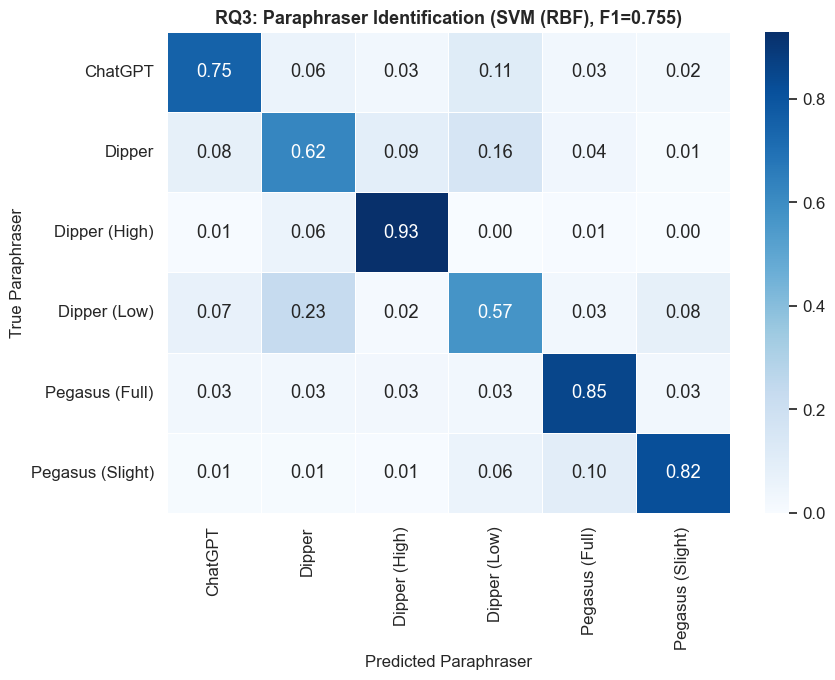

In [7]:
best_clf = max(rq3_results, key=lambda k: rq3_results[k]['macro_f1'])
best_r = rq3_results[best_clf]
display_labels = [LABELS.get(l, l) for l in best_r['labels']]

fig, ax = plt.subplots(figsize=(9, 7))
cm = best_r['confusion_matrix']
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=display_labels, yticklabels=display_labels,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Paraphraser', fontsize=12)
ax.set_ylabel('True Paraphraser', fontsize=12)
ax.set_title(f'RQ3: Paraphraser Identification ({best_clf}, F1={best_r["macro_f1"]:.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fingerprints' / 'paraphraser_confusion_matrix.png',
            dpi=300, bbox_inches='tight')
plt.show()


### Feature Importance

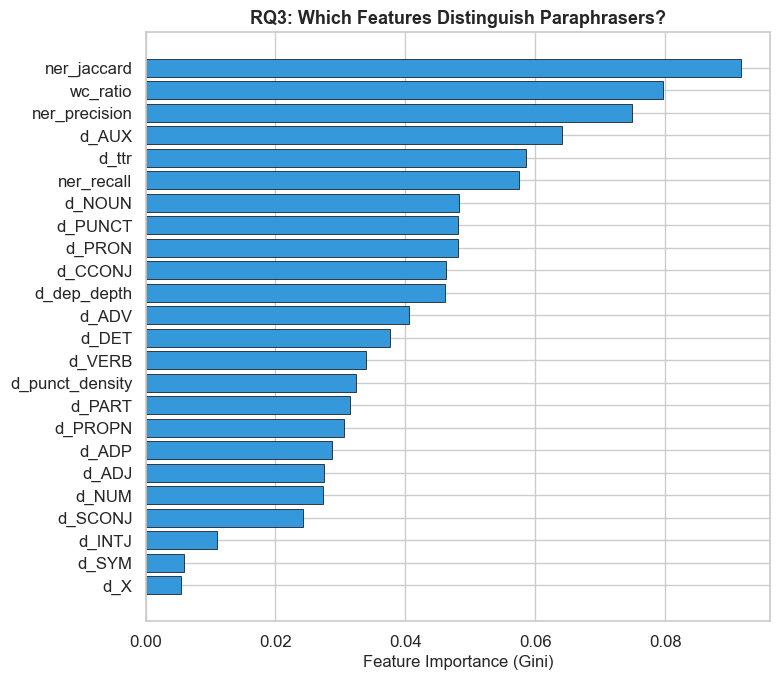

In [8]:
if 'feature_importance' in rq3_results.get('Random Forest', {}):
    importance = rq3_results['Random Forest']['feature_importance']
    imp_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Importance'])
    imp_df = imp_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='#3498db',
            edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
    ax.set_title('RQ3: Which Features Distinguish Paraphrasers?',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fingerprints' / 'paraphraser_feature_importance.png',
                dpi=300, bbox_inches='tight')
    plt.show()


---
## Domain-Specific Analysis

How do decay patterns vary across the 7 datasets (news, fiction, reviews, arguments, etc.)?


In [9]:
# Per-dataset metrics summary (Dipper)
df_dipper = multitier['dipper']
datasets = sorted(df_dipper['dataset'].unique())

domain_rows = []
for ds in datasets:
    mask = df_dipper['dataset'] == ds
    df_ds = df_dipper[mask].reset_index(drop=True)
    ent = np.mean([len(s) if isinstance(s, (set, frozenset)) else 0
                   for s in df_ds['ner_T0']])
    pos_t1 = df_ds['cos_T1'].dropna().mean()
    ner_t1 = df_ds['ner_recall_T1'].dropna().mean()
    domain_rows.append({'Dataset': ds, 'Entity Density': ent,
                        'POS Cosine T1': pos_t1, 'NER Recall T1': ner_t1})

domain_df = pd.DataFrame(domain_rows).sort_values('Entity Density', ascending=False)
domain_df = domain_df.set_index('Dataset')
print('Domain Profile (Dipper, T1):\n')
domain_df.round(4)


Domain Profile (Dipper, T1):



,Entity Density,POS Cosine T1,NER Recall T1
Dataset,,,
xsum,18.7342,0.9646,0.4614
sci_gen,10.2399,0.9644,0.4391
tldr,9.0475,0.9576,0.4174
cmv,7.5977,0.9758,0.4137
wp,7.2878,0.9743,0.4501
eli5,6.1797,0.9635,0.3989
yelp,5.8832,0.9581,0.3617


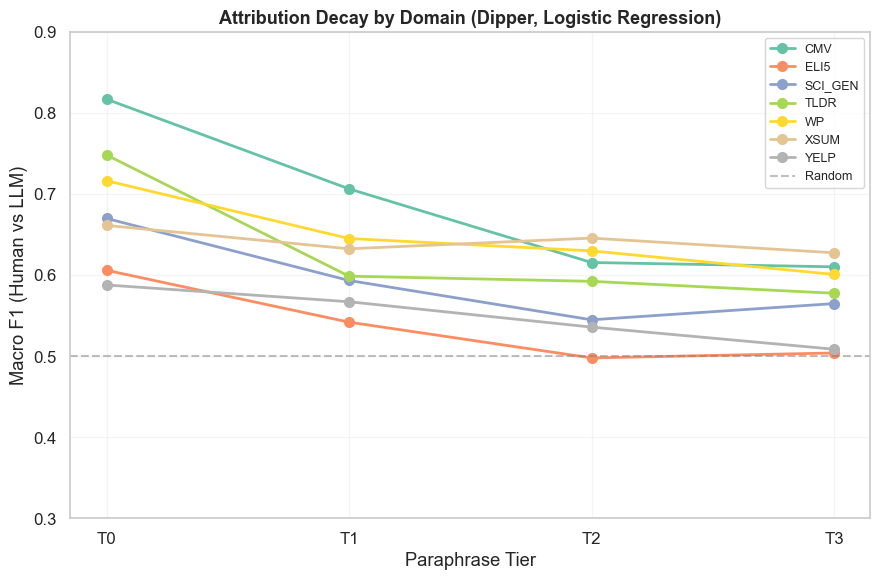

In [10]:
# Domain attribution decay curves
fig, ax = plt.subplots(figsize=(9, 6))
tiers_d = ['T0', 'T1', 'T2', 'T3']
x_d = range(len(tiers_d))
d_colors = plt.cm.Set2(np.linspace(0, 1, len(datasets)))

for i, ds in enumerate(datasets):
    mask = df_dipper['dataset'] == ds
    df_ds = df_dipper[mask].reset_index(drop=True)
    if len(df_ds) < 30:
        continue
    y = np.array(['Human' if s == 'Human' else 'LLM' for s in df_ds['source']])
    if len(set(y)) < 2:
        continue
    X_T0, _ = build_feature_vector(df_ds, 'T0')
    nan_mask = np.isnan(X_T0).any(axis=1)
    X_T0 = X_T0[~nan_mask]
    y_c = y[~nan_mask]
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import f1_score as f1
    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    clf.fit(scaler.fit_transform(X_T0), y_c)
    f1_vals = [f1(y_c, clf.predict(scaler.transform(X_T0)), average='macro')]
    for tier in ['T1', 'T2', 'T3']:
        tm = df_ds[f'text_{tier}'].notna().values & ~nan_mask
        if tm.sum() < 10:
            f1_vals.append(np.nan)
            continue
        X_t, _ = build_feature_vector(df_ds[tm], tier)
        f1_vals.append(f1(y[tm], clf.predict(scaler.transform(X_t)), average='macro'))
    ax.plot(x_d, f1_vals, 'o-', label=ds.upper(), color=d_colors[i], linewidth=2, markersize=7)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax.set_xticks(x_d)
ax.set_xticklabels(tiers_d)
ax.set_xlabel('Paraphrase Tier')
ax.set_ylabel('Macro F1 (Human vs LLM)')
ax.set_title('Attribution Decay by Domain (Dipper, Logistic Regression)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.3, 0.9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


**Key domain findings:**
- **XSum (news)**: Highest entity density (18.7/doc), best entity retention
- **CMV (arguments)**: Most resilient grammar + strongest attribution signal (F1=0.706 at T1)
- **Yelp (reviews)**: Most vulnerable across all metrics — casual register is easiest to launder
- **ELI5 (explanations)**: Attribution collapses nearest to chance — informal text has least distinctive style
- Entity density correlates with content resilience; register formality correlates with style resilience

---
## Summary

### RQ2: Point of No Return
Authorship attribution (Human vs LLM) degrades sharply at the first paraphrase iteration for most classifiers. Linear models (Logistic Regression) drop below F1=0.5 at T1 for aggressive paraphrasers like Dipper (High), marking the point of no return. Ensemble methods (Random Forest) retain higher accuracy but their F1 also degrades, suggesting the models exploit class imbalance rather than true authorial signal.

### RQ3: Paraphraser Fingerprints
A 6-class classifier achieves ~75% accuracy in identifying which paraphraser was used from T0→T1 delta features alone. This confirms that each paraphraser leaves a distinct forensic fingerprint. The confusion matrix reveals which paraphrasers are most confusable, and feature importance shows which linguistic dimensions (POS deltas, NER metrics, text compression) carry the most discriminative signal.